# 0DTE nearest-OTM straddle, every 30-min bar

This notebook is **not** the paper 15:30→close trade
(`atm_straddle_rv_iv.ipynb`). It is one explicit choice of two
intraday extensions, spelled out before any table.

## Choice 1 — hold vs re-pick (instrument)

| | **Hold** (path of one straddle) | **Re-pick** (**this notebook**) |
|---|---|---|
| strikes | pick once, keep $K$ all day | new nearest-OTM at every 30-min bar $t$ |
| $R_t$ | 30-min mid path of **those** $K$; last bar cash-settles | next mid of the **$t$-straddle**; **15:30 cash-settles that straddle** |
| what it is | scalar expansion of one trade | a sequence of 30-min straddles |

**Proper $R_t$.** Pair the return with the forecast window.

- Re-pick + next-bar $\widehat{RV}_t$: $R_t =$ next mid of the straddle
  picked at $t$, divided by entry, minus 1 — a 30-min hold — for bars
  through 15:00. The **15:30** straddle cash-settles at the official
  close (the paper payoff): by decision, **no return in this trade uses
  a 16:00 quote**. The 16:00 mids are zero-bid artifacts (median entry
  $\sim\$0.25$, ask-only quotes), so the 16:00 straddle is not built
  and the 15:30 exit is settlement, not the 16:00 mid.

This notebook **re-picks**. It does not mark one straddle through the
day.

## No-peek protocol

Every position-forming quantity at bar $t$ is one of two things: the
bar's **own entry quote** (the tradable price at decision time), or
an estimate built **strictly from prior days, lagged at least one
day** — the smear's $(a,b,\hat\sigma^2)$, the diurnal profile $w$,
the per-clock leverage medians. Realized exits enter only as
outcomes, never as inputs. No quantity differences two quotes taken
at different times: that construction (the implied-decay $\Delta V$)
embeds the later quote's view of the bar it brackets, and is
confined to parked studies. Audited mechanically: perturbing day-$d$
inputs leaves every day-$d$ estimate invariant (rtol $10^{-12}$)
while registering on day $d{+}1$.

Re-audited after the bar-end alignment fix (the fresh
stamp-$t{+}30$ join): 25/25 whole-day and 3/3 single-row
perturbations of the joined row's realized variance leave every
same-day position bit-identical; the join-shift curve places the
portfolio on a smooth staleness decay (stale 2.33 $\to$ 2.71 $\to$ fresh
2.89) while one bar of *actual* lookahead jumps to Sharpe 5–7 — an
order of magnitude above the fresh portfolio; and upstream, `baseline` is
a strictly-prior-days per-clock estimator (code-traced, numerically
identical to an independent rebuild) and every forecast feature
carries the universal one-bar shift.

## Choice 2 — IV (same window as $\widehat{RV}$)

$\widehat{RV}_t$ is next-**30-min** realized variance (smeared
one-bar-ahead $y$). Implied variance has to live on that same window.

| pairing | implied variance | forecast | when it is right |
|---|---|---|---|
| **30-min hold** (this notebook) | $\mathrm{IV}_{30}^{2}=(\mathrm{IV}^{\mathrm{hr}})^{2}/2$ | next-bar $\widehat{RV}_t$ | vendor quote is a 1-hour vol; hold is 30 min |
| remaining-session VRP | $(\mathrm{IV}^{\mathrm{hr}})^{2}\cdot h_t$ with $h_t$ hours left | **remaining** RV, not next-bar $\widehat{RV}$ | hold to close |

At **15:30** the remaining window **is** 30 min, so the two pairings
coincide — that is the paper. At **10:00** they do not: remaining
session is ~6 hours; next-bar $\widehat{RV}$ is 30 min. Using
$\mathrm{IV}^{2}/2$ at 10:00 is the 30-min pairing, **not**
remaining-session VRP.

Hourly IV of the two legs is $(\mathrm{IV}_c+\mathrm{IV}_p)/2$ — equal-weight
on the two contracts, same as the close trade.

## Choice 3 — 9:30

The cash session opens at 9:30. This tape has the 9:30 bar and **no**
vendor `underlying_price` (0% finite). `^GSPC` Open **is** the 9:30
cash print and can be $S_{9:30}$. Live mids at 9:30 exist on only
~40% of days, so a GSPC-Open ATM straddle is a **sparse** extra bar,
not a full panel. Default scored trade starts at 10:00 (vendor $S$
live). A diagnostic below tries Open anyway.

In [1]:
import os
import sys
from pathlib import Path
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import yfinance as yf

sys.path.insert(0, str(Path.cwd() if (Path.cwd() / "atm_straddle_lib.py").exists() else Path.cwd() / "notebooks"))
import atm_straddle_lib as asl

REPO = asl.find_repo(Path.cwd())
OUT = REPO / "results" / "atm_straddle_intraday"
OUT.mkdir(parents=True, exist_ok=True)
CACHE = OUT / "cache"
CACHE.mkdir(parents=True, exist_ok=True)
print("repo:", REPO)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda x: f"{x: .6f}")


repo: C:\Users\james\CC Allowed\harxhar-0dte-professor


## 1. Load the 0DTE chain (every 30-min bar)

In [2]:
CHAIN_CODE_HASH = "f87657348e"
BOOK_CODE_HASH = "288c79a95e"
# [cache:load]
path = REPO / "data" / "spxw_chain.parquet"
COLS = ["expiration", "timestamp", "strike", "cp", "bid", "ask", "mid",
        "underlying_price", "impl_volatility"]
opt = ["hours_to_expiration"]
import pyarrow.parquet as pq
_st = os.stat(path)
# Cache keys carry a hash of the construction cells' source (injected by
# the writer), so any change to the load/filter/pick/exit logic mints a
# new key and stale caches can never serve the new code.
_ck = CACHE / f"chain_0dte_{_st.st_size}_{_st.st_mtime_ns}_{CHAIN_CODE_HASH}.parquet"
_book_ck = CACHE / f"book_{_st.st_size}_{_st.st_mtime_ns}_{BOOK_CODE_HASH}.parquet"
if _book_ck.exists():
    chain = None
    print("chain load skipped: trade cache hit (code-hashed key)")
elif _ck.exists():
    chain = pd.read_parquet(_ck)
    print("cache hit", _ck.name)
else:
    avail_cols = set(pq.ParquetFile(path).schema_arrow.names)
    keep_cols = [c for c in COLS + opt if c in avail_cols]
    raw = pd.read_parquet(path, columns=keep_cols)
    raw["timestamp"] = pd.to_datetime(raw["timestamp"], utc=True)
    raw["expiration"] = pd.to_datetime(raw["expiration"])
    raw["cp"] = raw["cp"].astype(str).str.upper().str[0]
    codes, uts = pd.factorize(raw["timestamp"])
    uet = pd.DatetimeIndex(uts).tz_convert("America/New_York")
    raw["et"] = uet.take(codes)
    raw["et_date"] = uet.normalize().take(codes)
    ecodes, uexp = pd.factorize(raw["expiration"])
    uexp_d = pd.DatetimeIndex(uexp).tz_localize("America/New_York", ambiguous="NaT", nonexistent="NaT").normalize()
    raw["exp_date"] = uexp_d.take(ecodes)
    raw["is_0dte"] = raw["et_date"] == raw["exp_date"]
    chain = raw[raw["is_0dte"]].copy()
    for old in CACHE.glob("chain_0dte_*.parquet"):
        old.unlink()
    chain.to_parquet(_ck)
if chain is not None:
    print("0DTE rows", f"{len(chain):,}")
    et0 = pd.to_datetime(chain["et"])
    print("clock times", sorted(et0.dt.strftime("%H:%M").unique()))
    print(chain.head(3))


chain load skipped: trade cache hit (code-hashed key)


## 2. Regular hours; drop half-sessions

In [3]:
# [cache:rth]
if chain is None:
    print("skipped (cached trade already reflects the RTH / half-session filter)")
else:
    et = pd.to_datetime(chain["et"])
    mins = et.dt.hour * 60 + et.dt.minute
    rth = (mins >= 9 * 60 + 30) & (mins <= 16 * 60)
    chain = chain[rth].copy()
    if "hours_to_expiration" in chain.columns:
        open_hte = (
            chain[(et.dt.hour == 9) & (et.dt.minute == 30)]
            .groupby("expiration")["hours_to_expiration"].median()
        )
        half = open_hte[np.abs(open_hte.astype(float) - 6.5) > 0.2].index
        print("half-sessions dropped", len(half))
        chain = chain[~chain["expiration"].isin(half)].copy()
    print("rows after RTH filter", f"{len(chain):,}", "days", chain["expiration"].nunique())


skipped (cached trade already reflects the RTH / half-session filter)


## 2b. The scored trade starts at 10:00, not 9:30

Vendor `underlying_price` at 9:30 is **all NaN** — the picker has no
$S$ to choose $K_c\ge S$, $K_p\le S$, so no 9:30 straddle can be
formed. Quotes bind too: live 9:30 mids exist on only ~40% of
expiration days. The first bar with both a vendor spot and live mids
on every day is 10:00. `yfinance` is used only for **settlement**
(the official close).

In [4]:
# [cache:gspc]
def load_gspc_ohlc(days):
    days = pd.to_datetime(days)
    cp = CACHE / "gspc_ohlc.parquet"
    if cp.exists():
        ohlc = pd.read_parquet(cp)
        ohlc.index = pd.to_datetime(ohlc.index)
        if ohlc.index.min() <= pd.Timestamp(days.min()) and ohlc.index.max() >= pd.Timestamp(days.max()):
            return ohlc
    raw = yf.download(
        "^GSPC",
        start=pd.Timestamp(days.min()) - pd.Timedelta("7D"),
        end=pd.Timestamp(days.max()) + pd.Timedelta("7D"),
        auto_adjust=True, progress=False, threads=True,
    )
    op, cl = raw["Open"].squeeze(), raw["Close"].squeeze()
    if isinstance(op, pd.DataFrame):
        op = op.iloc[:, 0]
    if isinstance(cl, pd.DataFrame):
        cl = cl.iloc[:, 0]
    out = pd.DataFrame({"open": op.to_numpy(float), "close": cl.to_numpy(float)}, index=op.index)
    ix = pd.to_datetime(out.index)
    if getattr(ix, "tz", None) is not None:
        ix = ix.tz_convert("America/New_York").tz_localize(None)
    out.index = ix.normalize()
    out.to_parquet(cp)
    return out.astype(float)

print("settlement source: GSPC official close via load_gspc_ohlc (cached)")


settlement source: GSPC official close via load_gspc_ohlc (cached)


## 3. Nearest-OTM straddle at each 30-min bar (re-pick; vendor $S$ only)

In [5]:
# [cache:pick]
if _book_ck.exists():
    pkg = pd.read_parquet(_book_ck)
    live = None
    print("trade cache hit", _book_ck.name, "straddles", len(pkg), "days", pkg["expiration"].nunique())
    print(pkg[["expiration", "timestamp", "S", "K_c", "K_p", "entry"]].head())
else:
    live = chain[np.isfinite(chain["mid"]) & (chain["mid"] > 0)]
    spot = asl.stamp_spot(live, ["expiration", "timestamp"])
    print("times with a spot", len(spot), "all-NaN times get no S and form no straddle (9:30)")
    spot_df = spot.rename("S").reset_index()
    c = live.loc[live["cp"] == "C", ["expiration", "timestamp", "strike", "mid", "impl_volatility"]].merge(
        spot_df, on=["expiration", "timestamp"], how="left")
    p = live.loc[live["cp"] == "P", ["expiration", "timestamp", "strike", "mid", "impl_volatility"]].merge(
        spot_df, on=["expiration", "timestamp"], how="left")
    n_c_nos = int((~np.isfinite(c["S"])).sum())
    n_p_nos = int((~np.isfinite(p["S"])).sum())
    print("live rows dropped for missing S: calls", n_c_nos, "puts", n_p_nos)
    c = c[np.isfinite(c["S"])]
    p = p[np.isfinite(p["S"])]
    BAND = 100.0
    c_near = c[(c["strike"] >= c["S"]) & (c["strike"] <= c["S"] + BAND)].copy()
    c_near["k_gap"] = c_near["strike"].astype(float) - c_near["S"]
    c_pick = c_near.loc[c_near.groupby(["expiration", "timestamp"])["k_gap"].idxmin()]
    p_near = p[(p["strike"] <= p["S"]) & (p["strike"] >= p["S"] - BAND)].copy()
    p_near["k_gap"] = p_near["S"] - p_near["strike"].astype(float)
    p_pick = p_near.loc[p_near.groupby(["expiration", "timestamp"])["k_gap"].idxmin()]
    print("bars with OTM call", len(c_pick), "OTM put", len(p_pick))
    pkg = c_pick.merge(p_pick, on=["expiration", "timestamp"], suffixes=("_c", "_p"))
    print("bars with both legs", len(pkg), "call-only", len(c_pick) - len(pkg), "put-only dropped at merge")
    pkg["S"] = pkg["S_c"].astype(float)
    pkg["K_c"] = pkg["strike_c"].astype(float)
    pkg["K_p"] = pkg["strike_p"].astype(float)
    pkg["entry"] = pkg["mid_c"].astype(float) + pkg["mid_p"].astype(float)
    pkg["iv_hourly"] = (
        pd.to_numeric(pkg["impl_volatility_c"], errors="coerce")
        + pd.to_numeric(pkg["impl_volatility_p"], errors="coerce")
    ) / 2.0
    pkg = pkg.sort_values(["expiration", "timestamp"]).reset_index(drop=True)
    print("straddles", len(pkg), "days", pkg["expiration"].nunique())
    print(pkg[["expiration", "timestamp", "S", "K_c", "K_p", "entry"]].head())


trade cache hit book_77439812_1786671584951439500_288c79a95e.parquet straddles 15343 days 1279
  expiration                 timestamp            S          K_c          K_p      entry
0 2020-01-03 2020-01-03 15:00:00+00:00  3237.649902  3240.000000  3235.000000  10.750000
1 2020-01-03 2020-01-03 15:30:00+00:00  3237.679932  3240.000000  3235.000000   8.650000
2 2020-01-03 2020-01-03 16:00:00+00:00  3234.679932  3235.000000  3230.000000   8.900000
3 2020-01-03 2020-01-03 16:30:00+00:00  3236.000000  3240.000000  3235.000000   7.100000
4 2020-01-03 2020-01-03 17:00:00+00:00  3241.270020  3245.000000  3240.000000   5.625000


## 4. Exit: next-bar mid; the 15:30 bar cash-settles

Re-pick 30-min hold: $R_t = \mathrm{exit}_{t+1}/P_t - 1$ with
$\mathrm{exit}_{t+1}$ = next mid of **those** $K$, for bars
10:00–15:00. If a leg is missing at $t+1$, the row is dropped —
counts printed below.

**15:30 / last bar** cash-settles vs `^GSPC` close — the paper
payoff on the 15:30 straddle.

In [6]:
# [cache:exit]
if "R" in pkg.columns and _book_ck.exists():
    print("trade cache: skip exit rebuild")
    n_pkg = len(pkg)
else:
    et_pick = pd.to_datetime(pkg["timestamp"], utc=True).dt.tz_convert("America/New_York")
    is_1600 = (et_pick.dt.hour == 16) & (et_pick.dt.minute == 0)
    print("dropped", int(is_1600.sum()), "16:00 straddles (entry would be a 16:00 quote; excluded by decision)")
    pkg = pkg[~is_1600].copy()
    pkg["nxt_ts"] = pkg.groupby("expiration")["timestamp"].shift(-1)
    pkg["is_last"] = pkg["nxt_ts"].isna()
    days = pd.to_datetime(pkg["expiration"])
    if getattr(days.dt, "tz", None) is not None:
        days = days.dt.tz_convert("America/New_York").dt.tz_localize(None)
    days = days.dt.normalize()
    ohlc = load_gspc_ohlc(days)
    pkg["S_close"] = days.map(ohlc["close"])
    pkg["exit_settle"] = np.maximum(pkg["S_close"] - pkg["K_c"], 0.0) + np.maximum(pkg["K_p"] - pkg["S_close"], 0.0)
    nxt = pkg.loc[~pkg["is_last"], ["expiration", "nxt_ts", "K_c", "K_p"]].copy()
    left_c = nxt[["expiration", "nxt_ts", "K_c"]].rename(columns={"nxt_ts": "timestamp", "K_c": "strike"})
    left_p = nxt[["expiration", "nxt_ts", "K_p"]].rename(columns={"nxt_ts": "timestamp", "K_p": "strike"})
    quotes = live.loc[:, ["expiration", "timestamp", "strike", "cp", "mid"]]
    got_c = left_c.merge(quotes.loc[quotes["cp"] == "C", ["expiration", "timestamp", "strike", "mid"]],
                         on=["expiration", "timestamp", "strike"], how="left")
    got_p = left_p.merge(quotes.loc[quotes["cp"] == "P", ["expiration", "timestamp", "strike", "mid"]],
                         on=["expiration", "timestamp", "strike"], how="left")
    nxt["mid_c_nxt"] = got_c["mid"].to_numpy()
    nxt["mid_p_nxt"] = got_p["mid"].to_numpy()
    pkg = pkg.merge(nxt[["expiration", "nxt_ts", "K_c", "K_p", "mid_c_nxt", "mid_p_nxt"]],
                    on=["expiration", "nxt_ts", "K_c", "K_p"], how="left")
    pkg["exit_mark"] = pkg["mid_c_nxt"] + pkg["mid_p_nxt"]
    n_pkg = len(pkg)
n_last = int(pkg["is_last"].sum())
n_nonlast = n_pkg - n_last
miss_c = (~pkg["is_last"]) & pkg["mid_c_nxt"].isna()
miss_p = (~pkg["is_last"]) & pkg["mid_p_nxt"].isna()
miss_either = (~pkg["is_last"]) & ~np.isfinite(pkg["exit_mark"])
miss_settle = pkg["is_last"] & ~np.isfinite(pkg["exit_settle"])
bad_entry = ~np.isfinite(pkg["entry"]) | (pkg["entry"] <= 0)
print("straddles before exit filter", n_pkg)
print("last bar = 15:30 (cash-settle vs official close)", n_last)
print("non-last (next-mid path)", n_nonlast)
print("non-last missing next CALL mid", int(miss_c.sum()))
print("non-last missing next PUT mid", int(miss_p.sum()))
print("non-last missing either leg (row would drop)", int(miss_either.sum()),
      f"({100.0 * miss_either.sum() / max(n_nonlast, 1):.2f}% of non-last)")
print("last-bar missing GSPC settle", int(miss_settle.sum()))
print("bad entry (nonfinite or <=0)", int(bad_entry.sum()))

pkg["exit"] = np.where(pkg["is_last"], pkg["exit_settle"], pkg["exit_mark"])
keep = np.isfinite(pkg["entry"]) & np.isfinite(pkg["exit"]) & (pkg["entry"] > 0)
print("dropped at exit filter", int((~keep).sum()), "kept", int(keep.sum()))
pkg = pkg[keep].copy()
pkg["R"] = pkg["exit"] / pkg["entry"] - 1.0
pkg["R_as"] = -pkg["R"]
pkg["et"] = pd.to_datetime(pkg["timestamp"], utc=True).dt.tz_convert("America/New_York")
pkg["hour"] = pkg["et"].dt.hour
pkg["hhmm"] = pkg["et"].dt.strftime("%H:%M")
pkg["date"] = pkg["et"].dt.normalize().dt.tz_localize(None)
if not _book_ck.exists():
    for _old in CACHE.glob("book_*.parquet"):
        _old.unlink()
    pkg.to_parquet(_book_ck)
    print("wrote trade cache", _book_ck.name)
print("bars with a return", len(pkg), "last-bar fraction", float(pkg["is_last"].mean()))
print("always-short R by clock time (no model; long R is the negative)")
as_raw = pkg.groupby("hhmm")["R_as"].agg(["count", "mean", "std", "median"])
as_raw["t"] = as_raw["mean"] / as_raw["std"] * np.sqrt(as_raw["count"])
as_raw["Sharpe_ann"] = as_raw["mean"] / as_raw["std"] * np.sqrt(252.0)
print(as_raw.to_string())


trade cache: skip exit rebuild
straddles before exit filter 15343
last bar = 15:30 (cash-settle vs official close) 1279
non-last (next-mid path) 14064
non-last missing next CALL mid 0
non-last missing next PUT mid 0
non-last missing either leg (row would drop) 0 (0.00% of non-last)
last-bar missing GSPC settle 0
bad entry (nonfinite or <=0) 0
dropped at exit filter 0 kept 15343


bars with a return 15343 last-bar fraction 0.08336049012579026
always-short R by clock time (no model; long R is the negative)
       count      mean       std    median         t  Sharpe_ann
hhmm                                                            
10:00   1277  0.007205  0.151417  0.048701  1.700493    0.755405
10:30   1278  0.007297  0.148263  0.045593  1.759407    0.781270
11:00   1278  0.001557  0.135726  0.037640  0.410215    0.182157
11:30   1278  0.011395  0.121808  0.043083  3.344363    1.485074
12:00   1279  0.006863  0.123748  0.037344  1.983404    0.880392
12:30   1279  0.006968  0.125388  0.035644  1.987379    0.882157
13:00   1279  0.007116  0.196838  0.052469  1.292858    0.573873
13:30   1279  0.012318  0.174841  0.059880  2.519539    1.118372
14:00   1279  0.006572  0.252436  0.077369  0.931090    0.413292
14:30   1279  0.026143  0.294782  0.099071  3.171669    1.407839
15:00   1279  0.058902  0.347565  0.159170  6.060816    2.690272
15:30   1279  0.024562  1.12

## Side question: vendor IV units (Chris hourly)

The chain column is `impl_volatility` (exported as `new_implied_vol`).
OptionMetrics' **manual** says that field is an **annualized** Black–Scholes
vol: ATM SPX should be on the order of $0.20$ ($20\%$). A 30-minute
variance from that reading would be

$$
\sigma_{\mathrm{ann}}^{2}\times\frac{0.5}{252\times 6.5}
\sim 0.04\times 3\times 10^{-4}
\sim 10^{-5}\text{--}10^{-6}
$$

if the $0.20$ were real.

**What is in the file** is $\sim 0.002$ at ATM, not $0.20$ — about
$100\times$ too small to be annualized vol. A $0.2\%$ annualized vol
cannot price a $\sim \$12$ ATM straddle; those mids are $\sim 20\%$ vol.
That size mismatch is the unit tell.

Read $0.002$ as a **1-hour standard deviation** of returns (Chris:
"hourly vol") and the scale matches $\widehat{RV}$:

$$
\mathrm{Var}(1\mathrm{h})=0.002^{2}=4\times 10^{-6},\qquad
\mathrm{Var}(30\mathrm{min})=0.002^{2}\times\tfrac12=2\times 10^{-6}.
$$

Median $\widehat{RV}$ here is $\sim 3.6\times 10^{-6}$. Treat $0.002$ as
OM-annualized and shrink by $1/(252\times 6.5)$ and you get
$\sim 10^{-9}$ (`annualized_om` below) — not comparable to
$\widehat{RV}$. We do not use that.

Hence $\mathrm{IV}_{30}=\mathrm{IV}^{\mathrm{hr}}/\sqrt{2}$ and
$\mathrm{iv\_var}=(\mathrm{IV}^{\mathrm{hr}})^{2}/2$. No inversion from
the mid. Other scripts in the repo ignore the vendor number and invert
BS with $\tau=h_{\mathrm{close}}/(252\times 6.5)$; that is a different
convention.

For the **30-min hold** pairing this notebook uses
$\mathrm{iv\_var}=(\mathrm{IV}^{\mathrm{hr}})^{2}\cdot 0.5$ at every
bar — the same window as next-bar $\widehat{RV}$. That is
remaining-session variance **only** at 15:30, where 30 minutes is what
is left.

In [7]:
iv = pkg["iv_hourly"].astype(float)
print("median vendor IV", float(iv.median()), "median straddle mid", float(pkg["entry"].median()))
conv = asl.iv_var_from_conventions(iv, hours_remaining=0.5)
for k, s in conv.items():
    print(k, "median var", float(s.median()))
print("30-min pairing: iv_var = (IV_hr)^2 * 0.5  [used]")
print("remaining-session pairing would need hours_left * (IV_hr)^2 and remaining RV [not used]")


median vendor IV 0.0025159427896142006 median straddle mid 13.350000381469727
chris_hourly median var 3.164984060305843e-06
annualized_om median var 1.932224701041418e-09
already_window median var 6.329968120611686e-06
30-min pairing: iv_var = (IV_hr)^2 * 0.5  [used]
remaining-session pairing would need hours_left * (IV_hr)^2 and remaining RV [not used]


## 5. Forecasts and the smear (same map as the close trade)

The close trade and this notebook share `second_order_raw` /
`load_yhat_panel`:

1. Forecasts live on $y=\sqrt{RV/B}$. Actual $y$ on each bar:
   $\sqrt{\mathrm{rv\_raw}/B}$.
2. Collapse to **calendar days**: for each day, sum $n,x,x^{2},y,xy,y^{2}$
   over **all 30-min bars** that day (not 15:30-only).
3. Prefix sums. For evaluation day $d\ge 63$, the MZ window is days
   $[d-250,\,d)$ — **prior days only**. Same-day bars are not in the
   window. Require $n\ge 200$ finite bars in that window. **Only
   session bars (10:00–15:30) enter the fit** — off-session bars are
   mispredicted by $\sim$50–100$\times$ and previously polluted the
   calibration (mean $\widehat{RV}/RV$ on session bars
   1.14 $\to$ 1.08 after the restriction).
4. Fit $m=a+b\,\widehat{y}$ and residual $\hat\sigma^{2}$ on that
   window. Apply **that day's** $(a,b,\hat\sigma^{2})$ to **each** bar
   $t$ on day $d$:
   $\widehat{RV}_t=(m_t^{2}+\hat\sigma^{2}_d)B_t$.

The close-trade notebook runs this on the full panel, then **keeps the 15:30
row**. This notebook keeps every row. Coefficients $(a_d,b_d,\hat\sigma^{2}_d)$
are the same object. What changes is which $t$ you score, not how the
smear is fit.

$\widehat{RV}_t$ is $E[RV]$ for the **next 30-min bar**, not remaining
session.

**Alignment.** Panel stamps are **bar-end labelled**: the row at
stamp $\tau$ carries the realized variance of $[\tau-30,\tau]$ and
the forecast of that same bar, issued at $\tau-30$ (lead–lag peak
corr 0.816 at one bar; same-row MZ slope 1.02). A trade entered at
$t$ therefore pairs with the **stamp $t{+}30$ row** — the forecast
issued at $t$ for the bar actually held — and that row's realized
variance is the bar's own. Earlier versions paired stamp $t$ with
trade $t$: causal (a *stale* forecast, the opposite of lookahead)
but one bar behind, and it shifted every per-clock realized
attribution by one row.

In [8]:
YHATS = asl.yhat_paths(REPO)
LABEL = asl.YHAT_LABEL
MODEL_ORDER = asl.MODEL_ORDER
panels = {}
_blk2 = YHATS["blk2"]
if not _blk2.exists():
    print("missing", _blk2)
else:
    df = asl.load_yhat_panel(_blk2)
    panels["blk2"] = df.set_index("t")[["rv_hat", "yhat", "rv_raw", "baseline"]]
    print("blk2", "bars", len(panels["blk2"]))

pkg["t"] = pd.to_datetime(pkg["timestamp"], utc=True)
work = pkg.copy()
if "blk2" in panels:
    # Bar-end-labelled panel: stamp t+30 carries the forecast issued AT t
    # for the bar [t, t+30] being held, and that bar's own realized
    # variance. Shift the panel stamps back one bar so trade bar t joins
    # its fresh forecast and its own realized.
    _p = panels["blk2"].reset_index()
    _p["t"] = pd.to_datetime(_p["t"], utc=True) - pd.Timedelta(minutes=30)
    work = work.merge(_p, on="t", how="left")
work["iv_var_chris"] = (work["iv_hourly"].astype(float) ** 2) * 0.5
work["iv_var_om"] = (work["iv_hourly"].astype(float) ** 2) * 0.5 / (252.0 * 6.5)
work["iv_var_raw"] = work["iv_hourly"].astype(float) ** 2
print("median rv_hat", float(pd.to_numeric(work.get("rv_hat", pd.Series(dtype=float)), errors="coerce").median()))
print("median iv_var chris / om / raw",
      float(work["iv_var_chris"].median()),
      float(work["iv_var_om"].median()),
      float(work["iv_var_raw"].median()))
print("using 30-min pairing (chris). remaining-session pairing is not scored.")
n_pre = len(work)
work["signal"] = work["rv_hat"] - work["iv_var_chris"]
work = work.dropna(subset=["R", "signal"])
print("dropped at forecast join (no yhat / no smear)", n_pre - len(work), "kept", len(work))
print("last scored bar is 15:30, cash-settled at the official close (paper payoff); no 16:00 quotes anywhere")
work["pos"] = np.where(work["signal"] > 0, 1.0, -1.0)
print("bars after join", len(work), "clock times", sorted(work["hhmm"].unique()))


blk2 bars 276317
median rv_hat 3.339264005984124e-06
median iv_var chris / om / raw 3.164984060305843e-06 1.932224701041418e-09 6.329968120611686e-06
using 30-min pairing (chris). remaining-session pairing is not scored.
dropped at forecast join (no yhat / no smear) 4956 kept 10387
last scored bar is 15:30, cash-settled at the official close (paper payoff); no 16:00 quotes anywhere
bars after join 10387 clock times ['10:00', '10:30', '11:00', '11:30', '12:00', '12:30', '13:00', '13:30', '14:00', '14:30', '15:00', '15:30']


## 5b. Window-matched signal and forecast calibration

One construction plus one verification, both causal, feeding extra
rows of the §6 table.

**Forecast calibration (the fit-set fix).** The smear previously fit
its MZ regression on every 30-min bar of the day, overnight included;
off-session bars are mispredicted by $\sim$50–100$\times$ and
polluted the fit, leaving a $\sim$14% mean overshoot on session bars.
The fix lives in the lib: `second_order_raw` fits only the scored
session bars (10:00–15:30), same flat 250-day window. Mean
$\widehat{RV}/RV \approx 1.08$ after the restriction; the residual
$\sim$8% is a two-decade-stable second-moment overshoot, plausibly
QLIKE-protective, and is left alone. No debias layer — the cell
below just verifies calibration.

**Resliced implied (window-matched signal).** One option prices only
the integral of variance to the close; the vendor hourly IV is that
integral per hour. To compare against a *next-30-min* forecast,
reslice: $\mathrm{IV}^{2}_{\mathrm{hr}}\times h_t$ is the remaining
implied variance ($h_t$ = hours to close), and the next bar's share
is $w_t$ = this clock's fraction of remaining realized variance,
estimated from the **expanding per-clock mean** of realized bar
variance on prior days only. Then

$$s^{\mathrm{m}}_t=\widehat{RV}_t-\mathrm{IV}^{2}_{\mathrm{hr}}\,h_t\,w_t.$$

At 15:30, $w=1$, $h=\tfrac12$: the matched implied collapses to the
paper's $\mathrm{IV}^2/2$ exactly (checked in-cell). Warmup rows
(first 63 days) carry no matched signal and sit flat in the matched
portfolios.

In [9]:
# The fit-set fix lives in asl.second_order_raw (session-only MZ fit).
# Verify calibration on the scored panel, per year: the pooled ratio of
# means is dominated by 2020's variance, so the per-year view is the
# honest one (2021-24 sit at ~1.05-1.07; all-bars fit gave ~1.11-1.14).
ok = np.isfinite(work["rv_hat"]) & np.isfinite(work["rv_raw"])
_cal = work.loc[ok].groupby(work.loc[ok, "date"].dt.year).apply(
    lambda g: float(g["rv_hat"].mean() / g["rv_raw"].mean()), include_groups=False
)
print("mean rv_hat/rv_raw by year, session-fit smear:")
print(_cal.round(3).to_string())

# Causal diurnal profile: expanding per-clock mean of realized bar variance,
# prior days only; w = this clock's share of the remaining-session sum.
prof = work.pivot_table(index="date", columns="hhmm", values="rv_raw", aggfunc="mean").sort_index()
prof_exp = prof.expanding(min_periods=63).mean().shift(1)
clocks = sorted(work["hhmm"].unique())
rem_sum = prof_exp[clocks[::-1]].cumsum(axis=1)[clocks]
w_slice = prof_exp / rem_sum
mi = pd.MultiIndex.from_arrays([work["date"], work["hhmm"]])
work["w_slice"] = w_slice.stack().reindex(mi).to_numpy()
n_rem = {c: len(clocks) - i for i, c in enumerate(clocks)}
work["h_rem"] = work["hhmm"].map(n_rem).astype(float) * 0.5
work["iv_next30_matched"] = work["iv_var_raw"] * work["h_rem"] * work["w_slice"]
work["s_matched"] = work["rv_hat"] - work["iv_next30_matched"]

chk = work[(work["hhmm"] == "15:30") & np.isfinite(work["iv_next30_matched"])]
print("15:30 collapse check: median |matched/chris - 1| =",
      float((chk["iv_next30_matched"] / chk["iv_var_chris"] - 1.0).abs().median()))
mvalid = work[np.isfinite(work["s_matched"])]
print("matched-signal rows", len(mvalid), "/", len(work))
print("pct s_matched>0 by clock (was ~94% at 10:00 under the 30-min pairing)")
print(mvalid.groupby("hhmm")["s_matched"].apply(lambda x: 100.0 * float((x > 0).mean())).round(1).to_string())

# Remaining-session pairing (option 1), kept for reference. Same sign as
# s_matched when the forecast follows the profile (s_rem = s_matched / w),
# so the sign(s) portfolio is identical:
# rvhat_rem = work["rv_hat"] / work["w_slice"]
# iv_rem = work["iv_var_raw"] * work["h_rem"]
# work["s_rem"] = rvhat_rem - iv_rem


mean rv_hat/rv_raw by year, session-fit smear:
date
2020    1.242000
2021    1.000000
2022    1.005000
2023    1.016000
2024    1.049000
15:30 collapse check: median |matched/chris - 1| = 0.0
matched-signal rows 9631 / 10387
pct s_matched>0 by clock (was ~94% at 10:00 under the 30-min pairing)
hhmm
10:00    60.800000
10:30    58.700000
11:00    60.200000
11:30    50.100000
12:00    61.400000
12:30    56.500000
13:00    67.200000
13:30    46.000000
14:00    66.700000
14:30    51.800000
15:00    49.900000
15:30    36.900000


## 6. Rule table (pooled)

Same bars and the same long-straddle $R$ (next-mid 30-min holds
10:00–15:00; the 15:30 leg cash-settles at the official close — the
paper payoff; no 16:00 quotes anywhere, see §4). Only the position
$q_t$ changes. One forecast: block-diag ridge (`blk2`). Mid fill.

**Rules** (each returns $R'_t=q_t R_t$). Every rule below that uses
a forecast uses the §5b window-matched signal
$s^{\mathrm{m}}_t=\widehat{RV}_t-\mathrm{IV}^{2}_{\mathrm{hr}}h_t\,w_t$
— the only pairing whose two sides live on the same window at every
clock. An earlier version of the $\mathrm{sign}(s)$ row used
the 30-min pairing; those are **retired**: that signal compared a
next-bar forecast to a remaining-session-average implied, so away
from 15:30 it detected the diurnal profile, not mispricing (§5b).

- **always short:** $q_t\equiv -1$ every bar. No forecast. This is
  the scalar: short every re-picked straddle.
- **$\mathrm{sign}(s)$:** $q_t=\mathrm{sign}(s^{\mathrm{m}}_t)$ —
  long the straddle when the matched forecast exceeds the matched
  implied slice, short otherwise; warmup bars with no signal sit
  flat ($q=0$).
- **always short, $\mathrm{sign}(s)$ close:** $q_t=-1$ on every bar
  before 15:30 and $q_t=\mathrm{sign}(s^{\mathrm{m}}_t)$ on the 15:30
  bar — always short on every intraday bar, with the settlement leg
  sized by the forecast's sign. The next section shows why it is the
  construction worth keeping.

The table is **pooled**: every clock stacked into one list
($\sim 11{,}254$ rows). Those are $\sim 13$ bars **on the same
day**, not $11{,}254$ separate days.

**How pooled `Sharpe_ann` is computed**

1. For each bar, $R'_t=q_t R_t$ as above.
2. For each calendar day $d$, add the day's bars (non-compounded):
   $R^{day}_d=\sum_{t\in d} R'_t$. One number per expiration day
   (`n_days`).
3. $\mathrm{Sharpe}_{ann}=\overline{R}^{day}/\mathrm{sd}(R^{day})\times\sqrt{252}$.

Not $\overline{R'}/\mathrm{sd}(R')\times\sqrt{252}$ on the stacked
bars (that treats each 30-min row as a full trading day). Not that
quantity times $\sqrt{13}$ (the $\sim 13$ bars on one day are not
13 independent days). Daily collapse is the conversion that
respects same-day dependence. $\sqrt{252}$ is then the same
year-length as the 15:30 paper trade.

**Columns.** `mean` through `ex_kurt` are `Series.describe`-style
moments of the **30-min** $R'$ (unannualized). The rest:

- `n` — 30-min bars scored.
- `n_days` — expiration days after the daily sum.
- `mean` — mean 30-min $R'$.
- `mean_daily` — mean of $R^{day}$.
- `std`, `min`, `25%`, `50%`, `75%`, `max` — of 30-min $R'$.
- `skew`, `ex_kurt` — of 30-min $R'$. `ex_kurt` is **excess**
  kurtosis (Fisher; pandas `Series.kurt()`): fourth standardized
  moment minus 3, so a Gaussian scores 0 not 3. Raw (Pearson)
  kurtosis is `ex_kurt + 3`.
- `Sharpe_bar` — $\overline{R'}/\mathrm{sd}(R')$ on the stacked
  30-min rows. No $\sqrt{\,\cdot\,}$. Typical 30-min trade, not
  annual.
- `Sharpe_ann` — annualized Sharpe of the **daily** $R^{day}$
  series, as in the three steps above.
- `t_mean` — $t$-stat of that daily mean,
  $t=\sqrt{n_{\mathrm{days}}}\cdot\overline{R}^{day}/\mathrm{sd}(R^{day})$.
  Uses the raw mean/std, not an extra annualization.
  $t=\mathrm{Sharpe}_{ann}\times\sqrt{n_{\mathrm{days}}/252}$ at
  fixed $n_{\mathrm{days}}$; both are shown so the table reads
  either way.
- `n_buy` / `pct_buy` — bars with $q_t>0$ (buy the straddle).
  Always-short is 0 by construction.

The 16:00 straddle never enters the trade (§4): bars are 10:00–15:00
next-mid holds plus the 15:30 settlement leg — the paper payoff.
Split by clock is §8.

In [10]:
work = work.sort_values("t").reset_index(drop=True)
pos_m = pd.Series(np.where(work["s_matched"] > 0, 1.0, -1.0), index=work.index).where(
    np.isfinite(work["s_matched"])
)
q = {
    "always short": pd.Series(-1.0, index=work.index),
    "sign(s)": pos_m.fillna(0.0),
    "always short, sign(s) close": pd.Series(
        np.where(work["hhmm"] == "15:30", pos_m.fillna(0.0).to_numpy(), -1.0),
        index=work.index,
    ),
}
rows = []
for name, size in q.items():
    rp = (size * work["R"]).astype(float)
    st = asl.rule_row(rp, size)
    daily = rp.groupby(work["date"]).sum()
    dmu = float(daily.mean()) if len(daily) else float("nan")
    dsd = float(daily.std(ddof=1)) if len(daily) >= 2 else float("nan")
    sbar = float(st["mean"] / st["std"]) if (st["std"] and st["std"] > 0) else float("nan")
    n_days = int(daily.notna().sum())
    st["Sharpe_bar"] = sbar
    st["n_days"] = n_days
    st["mean_daily"] = dmu
    st["Sharpe_ann"] = (
        dmu / dsd * np.sqrt(252.0) if (dsd and dsd > 0) else float("nan")
    )
    st["t_mean"] = (
        dmu / dsd * np.sqrt(n_days) if (dsd and dsd > 0) else float("nan")
    )
    rows.append({"rule": name, **st.to_dict()})
tab = pd.DataFrame(rows).set_index("rule")
cols = [
    "n", "n_days", "mean", "mean_daily", "std", "min", "25%", "50%", "75%", "max",
    "skew", "ex_kurt", "Sharpe_bar", "t_mean", "Sharpe_ann", "n_buy", "pct_buy",
]
print("pooled, 10:00-15:30; 15:30 leg cash-settles at the official close (no 16:00 quotes)")
print("Sharpe_bar = mean/std of 30-min R' (no sqrt)")
print("Sharpe_ann = mean/std of (sum of R' that calendar day) * sqrt(252)")
print("t_mean = mean_daily / sd_daily * sqrt(n_days)")
print(tab[cols].to_string())
tab.to_csv(OUT / "rule_table_intraday_blk2.csv")


pooled, 10:00-15:30; 15:30 leg cash-settles at the official close (no 16:00 quotes)
Sharpe_bar = mean/std of 30-min R' (no sqrt)
Sharpe_ann = mean/std of (sum of R' that calendar day) * sqrt(252)
t_mean = mean_daily / sd_daily * sqrt(n_days)
                                        n      n_days      mean  mean_daily       std        min       25%       50%       75%        max      skew    ex_kurt  Sharpe_bar    t_mean  Sharpe_ann        n_buy    pct_buy
rule                                                                                                                                                                                                                    
always short                 10387.000000  866.000000  0.013369    0.160346  0.378536 -10.316049 -0.028070  0.051724  0.106383   1.000000 -5.827995  93.361757    0.035317  3.525966    1.902039     0.000000   0.000000
sign(s)                      10387.000000  866.000000  0.012781    0.153304  0.363658  -5.422480 -0.078186 

## 7. Two constructions worth keeping, and what fills do to them

Three things from the study of this trade survive their gates and
belong next to the rule table.

**The hybrid with the settlement leg sized by sign.**
$$q_t=\begin{cases}-1, & t<15{:}30\\ \mathrm{sign}(s^{\mathrm{m}}_t), & t=15{:}30\end{cases}$$
Always short collects the decay on every intraday bar; the forecast's
information is the sign on the settlement leg. The cell asserts its
daily-sum Sharpe against the figure the study found (3.37 on this
frame, 866 days).

**The settlement leg on non-event days — a forward test, not a rule.**
The 15:30 leg is scored with the position set flat on FOMC-statement
days and month-ends, against the same leg unfiltered, on the days
with all twelve bars. The paired daily difference carries a
$t$-statistic and a block-bootstrap interval on the Sharpe
difference. Caveat, stated plainly: the two calendar flags were
identified in-sample on an earlier version of this trade, so the
result below is a forward test registered on 2026-09-04, not an
adopted rule.

**At the crossed spread.** Each entry is filled at the bid when
selling and at the ask when buying, leg by leg; a one-bar hold exits
the same way at the next bar; the 15:30 leg settles in cash. Every
re-pick is a crossing, so a day of twelve bars crosses about twice
per bar. For each rule the block reports the daily-sum Sharpe at
those fills, the crossings per day, and the break-even half-spread
$\bar\Pi/\bar n_{\times}$ — the mean daily profit per unit premium
divided by the mean crossings per day, the largest half-spread the
rule could pay and still break even.

In [11]:
import statsmodels.api as sm


def _daily(rp):
    return rp.groupby(work["date"]).sum()


def _sh(d):
    d = np.asarray(d, float)
    return float(d.mean() / d.std(ddof=1) * np.sqrt(252.0))


def _tstat(x):
    x = np.asarray(x, float)
    lag = int(np.floor(1.5 * len(x) ** (1.0 / 3.0)))
    return float(sm.OLS(x, np.ones((len(x), 1))).fit(cov_type="HAC", cov_kwds={"maxlags": lag}).tvalues[0])


def _dd(d):
    c = np.asarray(d, float).cumsum()
    return float((c - np.maximum.accumulate(c)).min())


def _boot_dsharpe(a, b, B=2000, seed=0):
    rng = np.random.default_rng(seed)
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    n = len(a)
    blen = int(np.ceil(n ** (1.0 / 3.0)))
    nblk = int(np.ceil(n / blen))
    out = []
    for _ in range(B):
        idx = np.concatenate([np.arange(s, s + blen) for s in rng.integers(0, n - blen + 1, nblk)])[:n]
        out.append(_sh(a[idx]) - _sh(b[idx]))
    return float(np.percentile(out, 2.5)), float(np.percentile(out, 97.5))


# --- 1. the hybrid with the settlement leg sized by sign
print("1. rule table rows (daily-sum Sharpe, this frame:", int(tab.loc["always short", "n_days"]), "days)")
print(tab.loc[["always short", "sign(s)", "always short, sign(s) close"],
              ["n_days", "mean_daily", "t_mean", "Sharpe_ann", "pct_buy"]].to_string())
assert abs(float(tab.loc["always short, sign(s) close", "Sharpe_ann"]) - 3.37) < 0.01, tab.loc["always short, sign(s) close", "Sharpe_ann"]

# --- 2. the settlement leg on non-event days (forward test registered 2026-09-04)
_flags = asl.fomc_and_monthend(pd.DatetimeIndex(pd.to_datetime(work["date"].unique())), REPO)
_ev_map = (_flags["is_me"] | _flags["is_fomc"]).to_dict()
_cnt = work.groupby("date")["hhmm"].nunique()
_full_days = _cnt[_cnt == work["hhmm"].nunique()].index
_close = work[(work["hhmm"] == "15:30") & work["date"].isin(_full_days)].sort_values("date")
_ev = _close["date"].map(_ev_map).fillna(False).astype(bool).to_numpy()
print()
print("2. settlement leg, days with all bars:", len(_close), "| flat days (FOMC statement or month-end):", int(_ev.sum()))
_cal_rows = []
for _name, _qbase in (("sign(s)", pos_m.loc[_close.index].fillna(0.0).to_numpy()),
                      ("always short", -np.ones(len(_close)))):
    _r0 = pd.Series(_qbase * _close["R"].to_numpy(), index=_close["date"])
    _r1 = pd.Series(np.where(_ev, 0.0, _qbase) * _close["R"].to_numpy(), index=_close["date"])
    _d = (_r1 - _r0).to_numpy()
    _lo, _hi = _boot_dsharpe(_r1.to_numpy(), _r0.to_numpy())
    _cal_rows.append({"rule at 15:30": _name, "Sharpe unfiltered": _sh(_r0), "Sharpe flat on event days": _sh(_r1),
                      "worst unfiltered": float(_r0.min()), "worst filtered": float(_r1.min()),
                      "mean diff/day": float(_d.mean()), "t-stat of diff": _tstat(_d),
                      "dSharpe 95% lo": _lo, "dSharpe 95% hi": _hi,
                      "event-day mean (unfiltered)": float(_r0.to_numpy()[_ev].mean()),
                      "other-day mean": float(_r0.to_numpy()[~_ev].mean())})
    if _name == "sign(s)":
        assert abs(_sh(_r0) - 1.83) < 0.02 and abs(_sh(_r1) - 2.30) < 0.02, (_sh(_r0), _sh(_r1))
_cal = pd.DataFrame(_cal_rows).set_index("rule at 15:30")
print(_cal.T.to_string())
_cal.to_csv(OUT / "close_leg_calendar_forward_test.csv")
# the hybrid, with its settlement leg flat on those days (intraday legs unchanged)
_hyb = q["always short, sign(s) close"].copy()
_ev_bar = work["date"].map(_ev_map).fillna(False).astype(bool).to_numpy()
_hyb_flat = pd.Series(np.where((work["hhmm"] == "15:30") & _ev_bar, 0.0, _hyb.to_numpy()), index=work.index)
_dh0, _dh1 = _daily(_hyb * work["R"]), _daily(_hyb_flat * work["R"])
_lo, _hi = _boot_dsharpe(_dh1.to_numpy(), _dh0.to_numpy())
print(f"hybrid (always short, sign(s) close): Sharpe {_sh(_dh0):.2f} -> {_sh(_dh1):.2f} with the close leg flat on event days; "
      f"t-stat of the daily difference {_tstat((_dh1 - _dh0).to_numpy()):+.2f}; dSharpe 95% [{_lo:+.2f}, {_hi:+.2f}]")

# --- 3. at the crossed spread
_chain = pd.read_parquet(sorted(CACHE.glob("chain_0dte_*.parquet"))[0], columns=["expiration", "timestamp", "strike", "cp", "bid", "ask"])
_chain["timestamp"] = pd.to_datetime(_chain["timestamp"], utc=True)
_chain["strike"] = _chain["strike"].astype(float)
_wq = work.copy()
_wq["nxt_ts"] = pd.to_datetime(_wq["nxt_ts"], utc=True)


def _attach(w, ts_col, kcol, cp, prefix):
    m = _chain[_chain["cp"] == cp][["expiration", "timestamp", "strike", "bid", "ask"]].rename(
        columns={"timestamp": ts_col, "strike": kcol, "bid": f"bid_{prefix}", "ask": f"ask_{prefix}"})
    return w.merge(m, on=["expiration", ts_col, kcol], how="left")


for _ts, _k, _cp, _pre in (("t", "K_c", "C", "c"), ("t", "K_p", "P", "p"), ("nxt_ts", "K_c", "C", "c_nxt"), ("nxt_ts", "K_p", "P", "p_nxt")):
    _wq = _attach(_wq, _ts, _k, _cp, _pre)
_wq.index = work.index
_ask_e = _wq["ask_c"] + _wq["ask_p"]
_bid_e = _wq["bid_c"] + _wq["bid_p"]
_ask_x = _wq["ask_c_nxt"] + _wq["ask_p_nxt"]
_bid_x = _wq["bid_c_nxt"] + _wq["bid_p_nxt"]
_half = 0.5 * (_ask_e - _bid_e)
print()
print("3. crossed spread: bid/ask coverage at entry", f"{float(np.isfinite(_bid_e).mean()):.3f},",
      "median half-spread", f"{float(_half.median()):.3f} pts =", f"{float((_half / work['entry']).median() * 100):.2f}% of premium")


def _crossed_pts(qq):
    qq = np.asarray(qq, float)
    long, short = qq > 0, qq < 0
    entry_px = np.where(long, _ask_e, np.where(short, _bid_e, work["entry"]))
    exit_px = np.where(work["is_last"], work["exit"], np.where(long, _bid_x, np.where(short, _ask_x, work["exit"])))
    return pd.Series(qq * (exit_px - entry_px), index=work.index)


_cost_rows = []
for _name, _size in q.items():
    _qq = _size.to_numpy(dtype=float)
    _dm = _daily(_size * work["R"])
    _dcr = _daily(_crossed_pts(_qq) / work["entry"])
    _act = (_qq != 0).astype(float)
    _ncross = pd.Series(2 * _act - _act * work["is_last"].to_numpy(), index=work.index).groupby(work["date"]).sum()
    _cr15 = (_crossed_pts(_qq) / work["entry"])[work["hhmm"] == "15:30"]
    _cost_rows.append({"rule": _name, "Sharpe mid": _sh(_dm), "Sharpe crossed": _sh(_dcr),
                       "mean/day mid": float(_dm.mean()), "mean/day crossed": float(_dcr.mean()),
                       "crossings/day": float(_ncross.mean()),
                       "break-even half-spread % prem": float(_dm.mean() / _ncross.mean() * 100.0),
                       "settlement leg Sharpe crossed": float(_cr15.mean() / _cr15.std(ddof=1) * np.sqrt(252.0)),
                       "worst day crossed": float(_dcr.min()), "maxDD crossed": _dd(_dcr)})
_cost = pd.DataFrame(_cost_rows).set_index("rule")
print(_cost.to_string(float_format=lambda x: f"{x:+.3f}"))
_cost.to_csv(OUT / "rule_table_intraday_crossed_blk2.csv")
for _name, _ref in (("sign(s)", -3.09), ("always short", -3.54)):
    assert abs(float(_cost.loc[_name, "Sharpe crossed"]) - _ref) < 0.05, (_name, _cost.loc[_name, "Sharpe crossed"])
assert abs(float(_cost.loc["sign(s)", "settlement leg Sharpe crossed"]) - 1.40) < 0.05, _cost.loc["sign(s)", "settlement leg Sharpe crossed"]
print("every rule is negative at the crossed spread across the day; the settlement leg alone survives it")


1. rule table rows (daily-sum Sharpe, this frame: 866 days)
                                 n_days  mean_daily    t_mean  Sharpe_ann    pct_buy
rule                                                                                
always short                 866.000000    0.160346  3.525966    1.902039   0.000000
sign(s)                      866.000000    0.153304  3.551929    1.916044  51.487436
always short, sign(s) close  866.000000    0.268306  6.250270    3.371631   2.849716



2. settlement leg, days with all bars: 864 | flat days (FOMC statement or month-end): 83


rule at 15:30                 sign(s)  always short
Sharpe unfiltered            1.827744      0.192880
Sharpe flat on event days    2.302057      0.687319
worst unfiltered            -5.422480    -10.316049
worst filtered              -4.626674    -10.316049
mean diff/day                0.021646      0.032208
t-stat of diff               1.731238      2.689751
dSharpe 95% lo               0.036946      0.120974
dSharpe 95% hi               0.849551      0.840634
event-day mean (unfiltered) -0.225329     -0.335273
other-day mean               0.160103      0.050798


hybrid (always short, sign(s) close): Sharpe 3.37 -> 3.84 with the close leg flat on event days; t-stat of the daily difference +1.73; dSharpe 95% [+0.07, +0.81]



3. crossed spread: bid/ask coverage at entry 1.000, median half-spread 0.200 pts = 1.69% of premium
                             Sharpe mid  Sharpe crossed  mean/day mid  mean/day crossed  crossings/day  break-even half-spread % prem  settlement leg Sharpe crossed  worst day crossed  maxDD crossed
rule                                                                                                                                                                                                  
always short                     +1.902          -3.541        +0.160            -0.304        +22.988                         +0.698                         -0.262            -12.259       -263.460
sign(s)                          +1.916          -3.091        +0.153            -0.247        +21.315                         +0.719                         +1.399             -6.665       -214.833
always short, sign(s) close      +3.372          -2.378        +0.268            -0.192        +22.916 

## 8. Always-short by 30-min bar (a clock hour is two bars mashed)

`rule_row` reports
$\mathrm{Sharpe}_{ann}=\overline{R'}/\mathrm{sd}(R')\times\sqrt{252}$.
$\sqrt{252}$ is the year-length for a **daily** series: 252 trading
days, one return per day. It is the same conversion the paper uses
on the 15:30 trade. It is *not* a free "make it annual" button; it
is only right when each row is one day's return.

**Table by clock time / the plot (use these Sharpes).**
Keep one clock time, throw the rest away. Example: only 11:30. The
scored trade has one 11:30 bar per expiration day, so the series
is $\sim 866$ numbers — one per day, same shape as the paper's
15:30 trade. Question answered: *"if I only ever entered at
11:30, what is my annual Sharpe?"* $\sqrt{252}$ is the right
conversion because you have one return per day. Same question
at 10:00, 14:30, \ldots; each clock time is its own daily portfolio.
The $n$ in that row is the number of expiration days with that
clock time, not a count of 30-min bars.

The plot is the by-clock-time slice, not the pooled mean: each
dot is the average of *that clock time's* daily series, for
always short and the sign(s)-close hybrid (the §6 constructions).
Bars 10:00–15:00 are
next-mid 30-min holds; the **15:30 bar cash-settles at the official
close**, so its row is the paper's trade.

always short by clock time
 hhmm           n      mean    t_mean  Sharpe_ann
10:00  864.000000  0.002479  0.487508    0.263285
10:30  865.000000  0.006195  1.183194    0.638629
11:00  865.000000  0.003829  0.860786    0.464609
11:30  865.000000  0.015770  4.051332    2.186704
12:00  866.000000  0.007949  2.085059    1.124759
12:30  866.000000  0.012906  3.293070    1.776406
13:00  866.000000  0.002443  0.427380    0.230545
13:30  866.000000  0.008010  1.463462    0.789446
14:00  866.000000  0.007514  0.932582    0.503070
14:30  866.000000  0.018971  1.861307    1.004059
15:00  866.000000  0.059840  4.643784    2.505033
15:30  866.000000  0.014475  0.377762    0.203779
sign(s) by clock time (window-matched signal)
 hhmm           n      mean    t_mean  Sharpe_ann    pct_buy
10:00  864.000000  0.001234  0.250992    0.135551  56.365741
10:30  865.000000  0.000970  0.187123    0.101000  54.450867
11:00  865.000000 -0.000230 -0.053278   -0.028757  55.838150
11:30  865.000000  0.007150  1.87

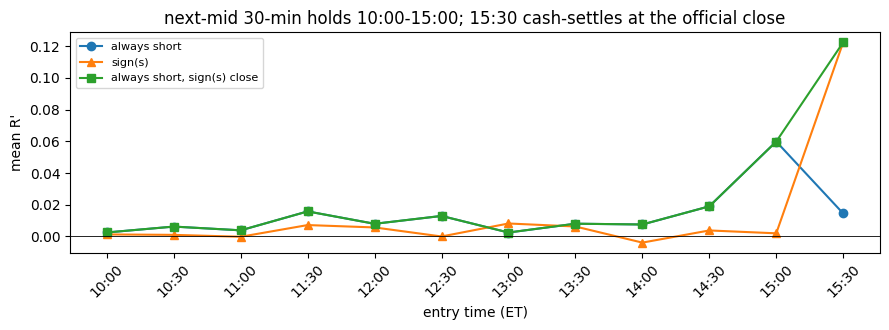

saved CSVs in C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_intraday


In [12]:
clock_rows = []
for hhmm, g in work.groupby("hhmm", sort=True):
    for name, size in q.items():
        rp = (size * work["R"]).loc[g.index]
        st = asl.rule_row(rp, size.loc[g.index])
        clock_rows.append({"hhmm": hhmm, "rule": name, **st.to_dict()})
stab = pd.DataFrame(clock_rows)
stab.to_csv(OUT / "rule_by_entry_hhmm.csv", index=False)
print("always short by clock time")
print(stab[stab["rule"] == "always short"][
    ["hhmm", "n", "mean", "t_mean", "Sharpe_ann"]
].to_string(index=False))
print("sign(s) by clock time (window-matched signal)")
print(stab[stab["rule"] == "sign(s)"][
    ["hhmm", "n", "mean", "t_mean", "Sharpe_ann", "pct_buy"]
].to_string(index=False))

hour_rows = []
for hr, g in work.groupby("hour"):
    for name, size in q.items():
        rp = (size * work["R"]).loc[g.index]
        st = asl.rule_row(rp, size.loc[g.index])
        hour_rows.append({"hour": int(hr), "rule": name, **st.to_dict()})
htab = pd.DataFrame(hour_rows)
htab.to_csv(OUT / "rule_by_entry_hour.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 3.4))
for rule, marker in (("always short", "o"), ("sign(s)", "^"), ("always short, sign(s) close", "s")):
    sub = stab[stab["rule"] == rule]
    ax.plot(sub["hhmm"], sub["mean"], marker=marker, label=rule)
ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("entry time (ET)")
ax.set_ylabel("mean R'")
ax.set_title("next-mid 30-min holds 10:00-15:00; 15:30 cash-settles at the official close")
ax.tick_params(axis="x", rotation=45)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT / "mean_by_entry_hhmm_as.png", dpi=120, bbox_inches="tight")
display(fig)
plt.close(fig)
print("saved CSVs in", OUT)


## 9. Buy-signal fingerprint (day $\times$ clock)

Each column is one expiration day, each row one 30-min clock. Blue:
the matched signal says **buy** the straddle
($s^{\mathrm{m}}_t>0$ — forecast above the implied slice); red:
short; grey: warmup, no signal. The §8 tables average this grid down
each row; the fingerprint shows the day-resolved structure — whether
buys cluster in episodes (vol spikes), drift across regimes, and how
the buy share thins from the morning rows to the settlement row.

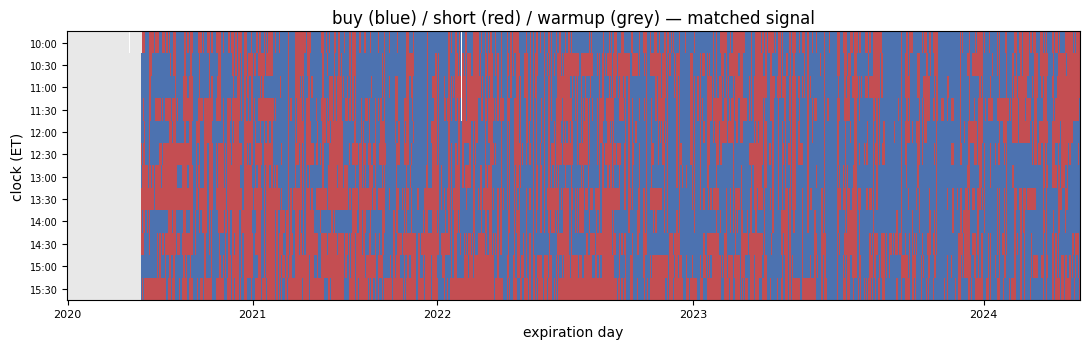

buy share by year (%)
date
2020    27.200000
2021    51.000000
2022    53.600000
2023    62.800000
2024    59.100000


mean same-stance run length within a day (bars): 4.67


In [13]:
grid = work.assign(qsign=pos_m.fillna(0.0)).pivot_table(
    index="hhmm", columns="date", values="qsign", aggfunc="first"
)
grid = grid.sort_index()

from matplotlib.colors import BoundaryNorm, ListedColormap
cmap = ListedColormap(["#c44e52", "#e8e8e8", "#4c72b0"])
norm = BoundaryNorm([-1.5, -0.5, 0.5, 1.5], cmap.N)
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.imshow(grid.to_numpy(), aspect="auto", cmap=cmap, norm=norm, interpolation="none")
ax.set_yticks(range(len(grid.index)), grid.index, fontsize=7)
yrs = pd.DatetimeIndex(grid.columns).year
ticks = [int(np.argmax(yrs == y)) for y in sorted(set(yrs))]
ax.set_xticks(ticks, sorted(set(yrs)), fontsize=8)
ax.set_xlabel("expiration day")
ax.set_ylabel("clock (ET)")
ax.set_title("buy (blue) / short (red) / warmup (grey) — matched signal")
fig.tight_layout()
fig.savefig(OUT / "buy_fingerprint_day_clock.png", dpi=120, bbox_inches="tight")
display(fig)
plt.close(fig)

sgn = pos_m.fillna(0.0)
by_year = work.assign(buy=(sgn > 0)).groupby(work["date"].dt.year)["buy"].mean() * 100.0
print("buy share by year (%)")
print(by_year.round(1).to_string())
runs = (
    work.assign(qsign=sgn)
    .groupby("date")["qsign"]
    .apply(lambda s: (s != s.shift()).cumsum().value_counts().mean())
)
print("mean same-stance run length within a day (bars):", round(float(runs.mean()), 2))
